In [1]:
# Pandas and numpy for data manipulation
import pandas as pd
import numpy as np
# No warnings about setting value on copy of slice
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', 60)
# Matplotlib for visualization
import matplotlib.pyplot as plt
%matplotlib inline
# Set default font size
plt.rcParams['font.size'] = 24
from IPython.core.pylabtools import figsize
# Seaborn for visualization
import seaborn as sns
sns.set(font_scale = 2)
# Imputing missing values
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import tree
# LIME for explaining predictions
import lime
import lime.lime_tabular

In [2]:
!pip install lime

In [3]:
from sklearn.ensemble import RandomForestRegressor

# Read in data into dataframes
train_features = pd.read_csv('training_features.csv')
test_features = pd.read_csv('testing_features.csv')
train_labels = pd.read_csv('training_labels.csv')
test_labels = pd.read_csv('testing_labels.csv')

if 'Datetime' in train_features.columns:
    train_features = train_features.drop(columns=['Datetime'])
if 'Datetime' in test_features.columns:
    test_features = test_features.drop(columns=['Datetime'])

no_CO = pd.read_csv('no_CO.csv')
no_CO = no_CO.drop(columns = ['CO'])
no_CO = no_CO.replace({np.inf: np.nan, -np.inf: np.nan})
if 'Datetime' in no_CO.columns:
    no_CO = no_CO.drop(columns=['Datetime'])

# Create an imputer object with a median filling strategy
imputer = SimpleImputer(strategy='median')

# Train on the training features
imputer.fit(train_features)

# Transform training data, testing data, and the no_CO data
X = imputer.transform(train_features)
X_test = imputer.transform(test_features)
missing_scores = imputer.transform(no_CO)

# Sklearn wants the labels as one-dimensional vectors
y = np.array(train_labels).reshape((-1,))
y_test = np.array(test_labels).reshape((-1,))

# Function to calculate mean absolute error
def mae(y_true, y_pred):
    return np.mean(abs(y_true - y_pred))

# Initialize the Random Forest Model
# We use the parameters based on the Breiman (2001) theory
model = RandomForestRegressor(n_estimators=800, 
                              max_depth=5, 
                              max_features=None, 
                              min_samples_leaf=8, 
                              min_samples_split=6, 
                              random_state=42,
                              n_jobs=-1)

# Fit the model
model.fit(X, y)

# Make predictions on the test set
model_pred = model.predict(X_test)

print('Final Random Forest Performance on the test set: MAE = %0.4f' % mae(y_test, model_pred))


Final Random Forest Performance on the test set: MAE = 0.5171


In [4]:
# Extract the feature importances into a dataframe
feature_results = pd.DataFrame({'feature':
list(train_features.columns),
 'importance':
model.feature_importances_})
# Show the top 10 most important
feature_results = feature_results.sort_values('importance',
ascending = False).reset_index(drop=True)
feature_results.head(10)

,feature,importance
0,PT08.S1(CO),0.911149
1,month,0.039815
2,hour,0.027564
3,log_AH,0.009047
4,RH,0.008728
5,T,0.003697


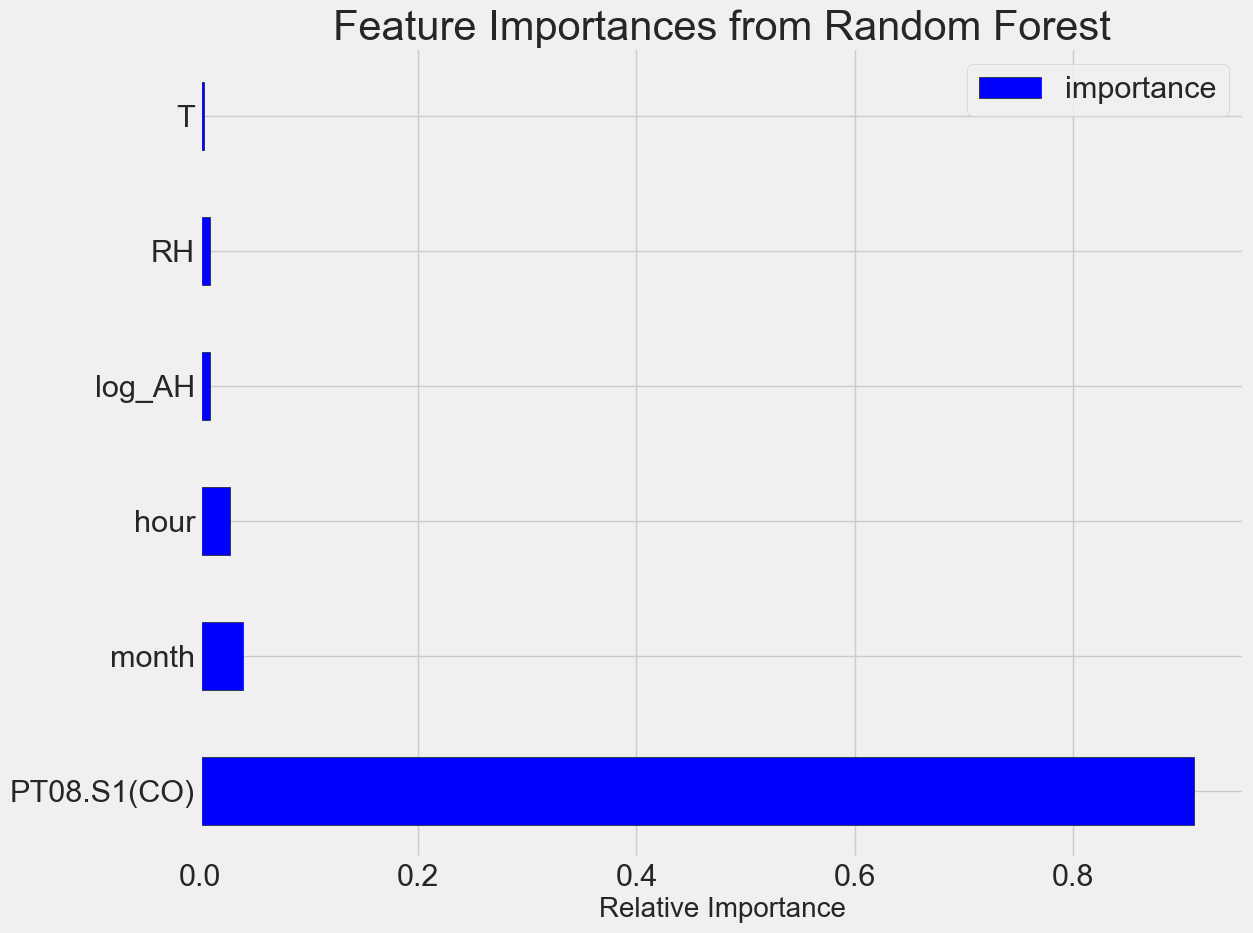

In [5]:
figsize(12, 10)
plt.style.use('fivethirtyeight')
# Plot the 10 most important features in a horizontal
#bar chart
feature_results.loc[:9, :].plot(x = 'feature', y =
'importance',
 edgecolor = 'k',
 kind='barh', color ='blue');
plt.xlabel('Relative Importance', size = 20);
plt.ylabel('')
plt.title('Feature Importances from Random Forest', size = 30);
plt.show()